# SRV cx_level Conditioning Evaluation

Evaluates whether the fine-tuned SRV model successfully steers CX gate density
via the `; cx_level=low/medium/high` text suffix.

**Conditions compared**
- `baseline`: model prompted without any cx_level suffix (unconditional)
- `low / medium / high`: cx_level suffix added to the SRV prompt

**Metrics**
- SRV exact-match accuracy per condition (does conditioning hurt generation quality?)
- Mean cx_ratio (n_cx / n_gates) per condition (does low < medium < high?)
- Mean n_cx per condition
- cx_ratio distributions (violin/box)

In [1]:
from notebooks.shared.bootstrap import setup_notebook_paths
PROJECT_ROOT = setup_notebook_paths()

import random
import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

from hydra.core.global_hydra import GlobalHydra
import hydra

from my_genQC.inference.sampling import generate_tensors
from quantum_diffusion.evaluation.evaluator import SRVEvaluator
from notebooks.shared.evaluation_artifacts import make_artifact_dir, save_figure, save_dataframe, save_json, save_pickle

plt.rcParams.update({
    "figure.dpi": 150, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.labelsize": 11, "axes.labelpad": 6,
    "axes.grid": True, "grid.linestyle": "--", "grid.linewidth": 0.6,
    "grid.alpha": 0.5, "grid.color": "#AAAAAA", "axes.axisbelow": True,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "legend.framealpha": 0.92, "legend.edgecolor": "#CCCCCC",
    "lines.linewidth": 2.0, "lines.markersize": 6, "font.family": "sans-serif",
})

In [2]:
# --- Config ---
FINETUNED_MODEL_DIR = "./artifacts/models/srv-noise-conditioning/srv_noise_finetuned"
BASELINE_MODEL_DIR  = "./artifacts/models/srv-baseline-reproduction/paper_stage_2"

DATASET_BASE    = "./artifacts/datasets/srv-datasets/quditkit"
QUBIT_COUNTS    = [3, 4, 5, 6]          # focus on smaller circuits for speed
SAMPLES_PER_SRV = 64                    # circuits generated per (SRV, condition)
GUIDANCE_SCALE  = 7.5
MAX_GATES       = 52
SEED            = 42

CONDITIONS = ["baseline", "low", "medium", "high"]
COLORS     = {
    "baseline": "#888888",
    "low":      "#2176AE",
    "medium":   "#3BAA6E",
    "high":     "#E05C2A",
}

ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, "srv-noise-conditioning", "cx_level_eval")

In [3]:
# --- Load finetuned pipeline ---
GlobalHydra.instance().clear()
with hydra.initialize(version_base=None, config_path="../../../conf"):
    cfg = hydra.compose(config_name="config.yaml",
                        overrides=["evaluation=paper_srv",
                                   f"evaluation.model_params.guidance_scale={GUIDANCE_SCALE}"])
eval_cfg = cfg["evaluation"]
eval_cfg.model_dir = str(Path(FINETUNED_MODEL_DIR).resolve())
eval_cfg.hf_repo   = None
eval_cfg.num_samples = SAMPLES_PER_SRV
eval_cfg.max_gates   = MAX_GATES
eval_cfg.save_output = False
eval_cfg.wandb.enable = False
eval_cfg.dataset = str(Path(f"{DATASET_BASE}/srv_{QUBIT_COUNTS[0]}q_dataset").resolve())

evaluator = SRVEvaluator(config=eval_cfg)
pipeline  = evaluator.pipeline
print("Pipeline loaded from", FINETUNED_MODEL_DIR)

[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
2026-05-28 07:05:30 - quantum_diffusion.evaluation.evaluator - INFO - Running w/o wandb


2026-05-28 07:05:30 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_x.safetensors` onto device: cuda.


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-28 07:05:31 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset


[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/srv-noise-conditioning/srv_noise_finetuned/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet`. Freeze model: True


[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/srv-noise-conditioning/srv_noise_finetuned/embedder.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Cond_UNet`. Freeze model: True
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...


Pipeline loaded from ./artifacts/models/srv-noise-conditioning/srv_noise_finetuned


In [4]:
# --- Build test SRV list ---
ds_y = torch.load(
    "artifacts/datasets/srv-noise-conditioning/dataset/ds_y.pt",
    weights_only=False
)["0"]

base_srvs = sorted(set(lbl.split("; cx_level=")[0] for lbl in ds_y))
print(f"{len(base_srvs)} unique SRVs total")

import ast
def srv_nqubits(srv_str):
    # SRV has n entries for n qubits (one Schmidt rank per qubit bipartition)
    bracket = srv_str[srv_str.find("["):srv_str.find("]")+1]
    return len(ast.literal_eval(bracket))

test_srvs = [s for s in base_srvs if srv_nqubits(s) in QUBIT_COUNTS]
print(f"{len(test_srvs)} SRVs for qubit counts {QUBIT_COUNTS}")
print("Sample:", test_srvs[:3])
print("Qubit counts:", [srv_nqubits(s) for s in test_srvs[:6]])

471 unique SRVs total
102 SRVs for qubit counts [3, 4, 5, 6]
Sample: ['Generate SRV: [1, 1, 1, 1, 1, 1]', 'Generate SRV: [1, 1, 1, 1, 1]', 'Generate SRV: [1, 1, 1, 1, 2, 2]']
Qubit counts: [6, 5, 6, 4, 6, 6]


In [5]:
# --- Generate circuits for each SRV × condition ---
# Two passes:
#   max_gates=52  → matches training distribution, used for cx_ratio measurement
#   max_gates=16  → matches quditkit eval tokenizer, used for SRV accuracy check
# NOTE: system_size = n_qubits (spatial dim of the noise tensor), NOT max_gates.
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

MAX_GATES_CX   = 52   # for cx_ratio measurement
MAX_GATES_ACC  = 16   # for SRV accuracy (must match eval tokenizer)

def make_prompt(srv_str, condition):
    if condition == "baseline":
        return srv_str
    return f"{srv_str}; cx_level={condition}"

def cx_stats(tensor):  # tensor: [N, n_qubits, max_gates]
    n_cx    = (tensor == -2).any(dim=1).sum(dim=1).float().cpu().numpy()
    n_gates = (tensor != 3).any(dim=1).sum(dim=1).float().cpu().numpy()
    n_gates = np.where(n_gates > 0, n_gates, 1.0)
    return n_cx, n_cx / n_gates

results     = defaultdict(lambda: defaultdict(dict))
acc_tensors = defaultdict(lambda: defaultdict(dict))

for srv in test_srvs:
    nq = srv_nqubits(srv)
    for condition in CONDITIONS:
        prompts = [make_prompt(srv, condition)] * SAMPLES_PER_SRV
        with torch.no_grad():
            # Pass 1: max_gates=52 for cx_ratio (system_size = n_qubits!)
            t52 = generate_tensors(
                pipeline=pipeline, prompt=prompts, samples=SAMPLES_PER_SRV,
                system_size=nq, num_of_qubits=nq, max_gates=MAX_GATES_CX,
                g=GUIDANCE_SCALE, enable_params=False, no_bar=True,
            )
            # Pass 2: max_gates=16 for SRV accuracy
            t16 = generate_tensors(
                pipeline=pipeline, prompt=prompts, samples=SAMPLES_PER_SRV,
                system_size=nq, num_of_qubits=nq, max_gates=MAX_GATES_ACC,
                g=GUIDANCE_SCALE, enable_params=False, no_bar=True,
            )
        n_cx, cx_ratio = cx_stats(t52)
        results[srv][condition]      = {"n_cx": n_cx, "cx_ratio": cx_ratio}
        acc_tensors[srv][condition]  = t16.cpu()

print(f"Generated {len(test_srvs) * len(CONDITIONS) * SAMPLES_PER_SRV * 2:,} circuits total")

Generated 52,224 circuits total


In [6]:
# --- Decode and check SRV accuracy (using max_gates=16 tensors) ---
import ast
from my_genQC.inference.evaluation_helper import get_srvs

def target_srv_list(srv_str):
    bracket = srv_str[srv_str.find("["):srv_str.find("]")+1]
    return ast.literal_eval(bracket)

evaluators_by_q = {}
for nq in QUBIT_COUNTS:
    GlobalHydra.instance().clear()
    with hydra.initialize(version_base=None, config_path="../../../conf"):
        cfg_q = hydra.compose(config_name="config.yaml",
                              overrides=["evaluation=paper_srv",
                                         f"evaluation.model_params.guidance_scale={GUIDANCE_SCALE}"])
    eval_cfg_q = cfg_q["evaluation"]
    eval_cfg_q.model_dir  = str(Path(FINETUNED_MODEL_DIR).resolve())
    eval_cfg_q.hf_repo    = None
    eval_cfg_q.dataset    = str(Path(f"{DATASET_BASE}/srv_{nq}q_dataset").resolve())
    eval_cfg_q.max_gates  = MAX_GATES_ACC
    eval_cfg_q.save_output = False
    eval_cfg_q.wandb.enable = False
    evaluators_by_q[nq] = SRVEvaluator(config=eval_cfg_q)

device = pipeline.device

acc_rows = []
for srv in test_srvs:
    nq  = srv_nqubits(srv)
    tgt = target_srv_list(srv)
    ev  = evaluators_by_q[nq]
    for condition in CONDITIONS:
        tensors = acc_tensors[srv][condition].to(device)
        decoded = ev.decode_tensors(tensors)
        valid_circuits = [qc for qc in decoded if qc is not None]
        if valid_circuits:
            pred_srvs = get_srvs(ev.simulator, valid_circuits, n_jobs=1)
            correct = sum(1 for p in pred_srvs if list(p) == tgt)
        else:
            correct = 0
        acc_rows.append({
            "srv": srv, "n_qubits": nq, "condition": condition,
            "accuracy": correct / len(decoded) if decoded else 0.0,
            "n_correct": correct, "n_total": len(decoded),
        })
    print(f"  {srv[:40]}… done")

acc_df = pd.DataFrame(acc_rows)
print("\nAccuracy by condition:")
print(acc_df.groupby("condition")["accuracy"].mean().loc[CONDITIONS].round(4).to_string())

[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
2026-05-28 07:09:22 - quantum_diffusion.evaluation.evaluator - INFO - Running w/o wandb


2026-05-28 07:09:22 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_x.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-28 07:09:22 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/srv-datasets/quditkit/srv_3q_dataset


[INFO]: `genQC.models.unet_qc.QC_Cond_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/srv-noise-conditioning/srv_noise_finetuned/model.pt` onto device: cuda.


[INFO]: `genQC.models.unet_qc.QC_Cond_UNet`. Freeze model: True


...

2026-05-28 07:10:07 - quantum_diffusion.evaluation.evaluator - INFO - Decoding tensors...


2026-05-28 07:10:08 - quantum_diffusion.evaluation.evaluator - INFO - Finished tensor decoding. Took 0.03 seconds.


2026-05-28 07:10:08 - quantum_diffusion.evaluation.evaluator - INFO - Decoding tensors...


2026-05-28 07:10:08 - quantum_diffusion.evaluation.evaluator - INFO - Finished tensor decoding. Took 0.02 seconds.


  Generate SRV: [2, 2, 2]… done

Accuracy by condition:
condition
baseline    0.0663
low         0.9115
medium      0.8664
high        0.9562


In [7]:
# --- CX summary table ---
cx_rows = []
for srv in test_srvs:
    nq = srv_nqubits(srv)
    for condition in CONDITIONS:
        r = results[srv][condition]
        cx_rows.append({
            "srv": srv, "n_qubits": nq, "condition": condition,
            "mean_n_cx":    r["n_cx"].mean(),
            "mean_cx_ratio": r["cx_ratio"].mean(),
        })

cx_df = pd.DataFrame(cx_rows)
summary = cx_df.groupby("condition")[["mean_n_cx", "mean_cx_ratio"]].mean().round(3)
print(summary.loc[CONDITIONS])

save_dataframe(acc_df, ARTIFACT_DIR / "accuracy.csv")
save_dataframe(cx_df,  ARTIFACT_DIR / "cx_stats.csv")

           mean_n_cx  mean_cx_ratio
condition                          
baseline      13.517          0.699
low            2.937          0.366
medium        13.061          0.632
high           6.328          0.790


PosixPath('/home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/srv-noise-conditioning/cx_level_eval/cx_stats.csv')

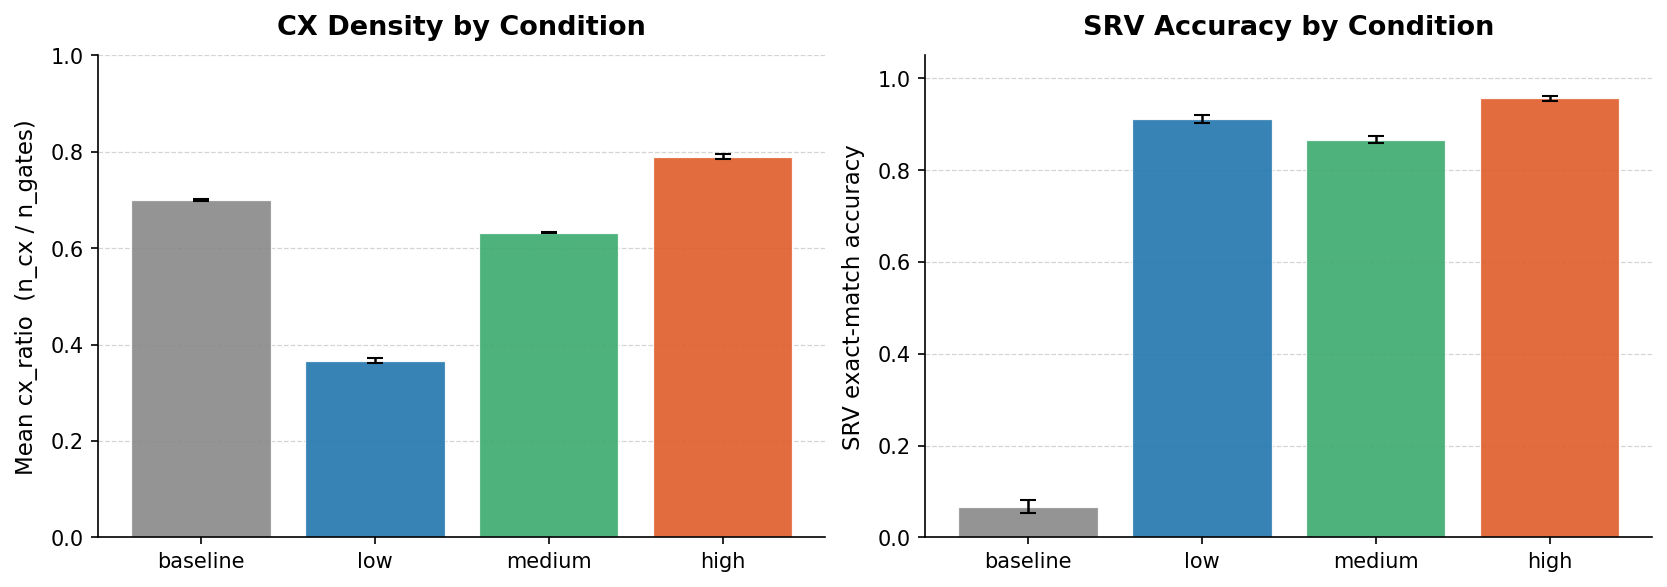

In [8]:
# --- Figure 1: cx_ratio and accuracy by condition ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

# Left: mean cx_ratio per condition (bar chart)
ax = axes[0]
means = cx_df.groupby("condition")["mean_cx_ratio"].mean().loc[CONDITIONS]
sems  = cx_df.groupby("condition")["mean_cx_ratio"].sem().loc[CONDITIONS]
bars = ax.bar(CONDITIONS, means.values, yerr=sems.values,
              color=[COLORS[c] for c in CONDITIONS],
              alpha=0.9, edgecolor="white", linewidth=0.6,
              error_kw=dict(elinewidth=1.2, capsize=4))
ax.set_ylabel("Mean cx_ratio  (n_cx / n_gates)")
ax.set_title("CX Density by Condition")
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_ylim(0, min(1.0, means.max() * 1.35))

# Right: SRV accuracy per condition
ax = axes[1]
acc_means = acc_df.groupby("condition")["accuracy"].mean().loc[CONDITIONS]
acc_sems  = acc_df.groupby("condition")["accuracy"].sem().loc[CONDITIONS]
ax.bar(CONDITIONS, acc_means.values, yerr=acc_sems.values,
       color=[COLORS[c] for c in CONDITIONS],
       alpha=0.9, edgecolor="white", linewidth=0.6,
       error_kw=dict(elinewidth=1.2, capsize=4))
ax.set_ylabel("SRV exact-match accuracy")
ax.set_title("SRV Accuracy by Condition")
ax.yaxis.grid(True); ax.xaxis.grid(False)
ax.set_ylim(0, 1.05)

save_figure(fig, ARTIFACT_DIR / "cx_ratio_and_accuracy_by_condition.png")
plt.show()

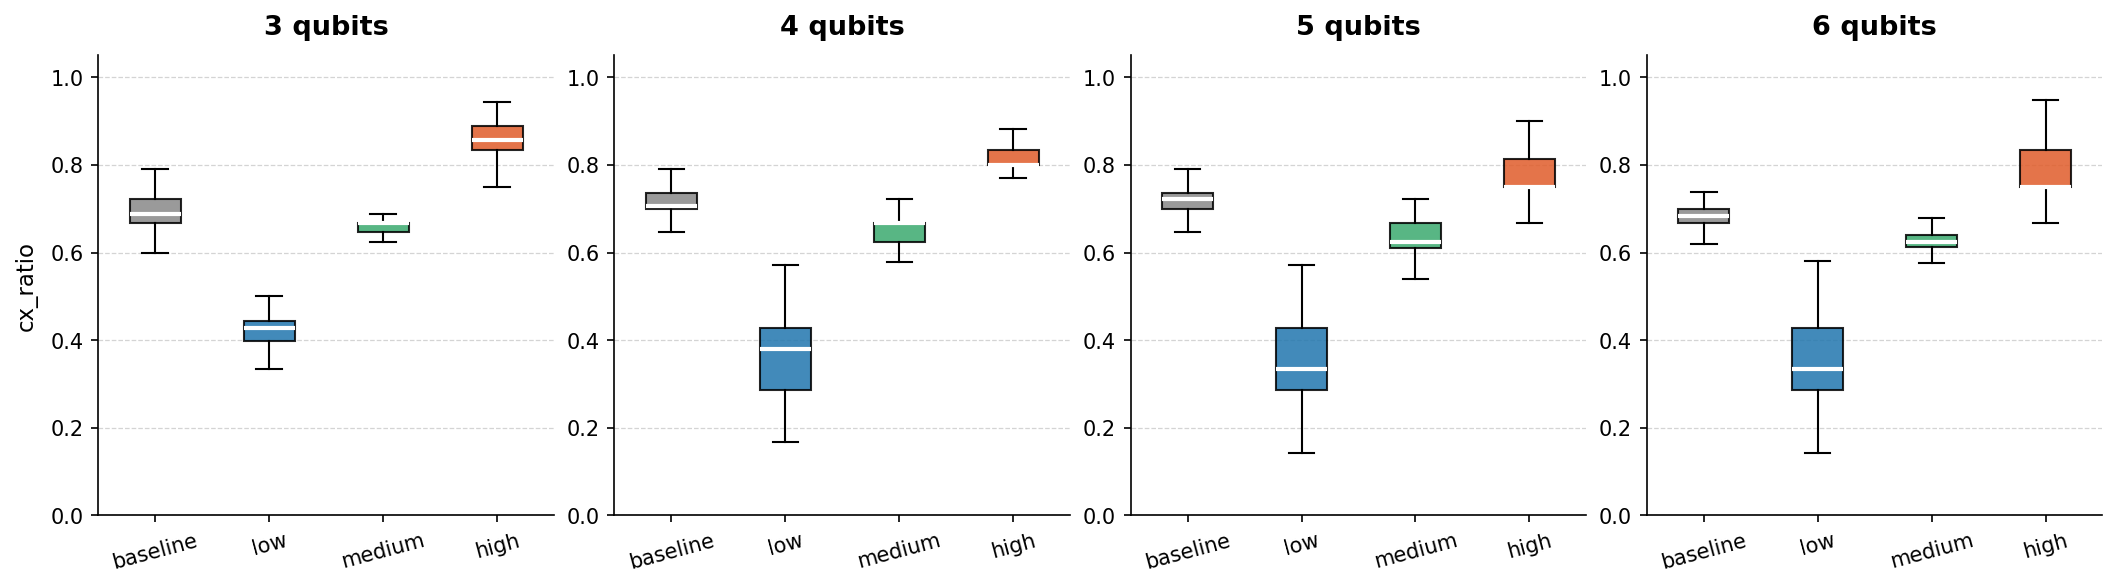

In [9]:
# --- Figure 2: cx_ratio distributions (box plots) per condition × qubit count ---
fig, axes = plt.subplots(1, len(QUBIT_COUNTS), figsize=(3.5 * len(QUBIT_COUNTS), 3.8),
                          constrained_layout=True)

for ax, nq in zip(axes, QUBIT_COUNTS):
    data = []
    for condition in CONDITIONS:
        vals = []
        for srv in test_srvs:
            if srv_nqubits(srv) == nq:
                vals.extend(results[srv][condition]["cx_ratio"].tolist())
        data.append(vals)

    bp = ax.boxplot(data, patch_artist=True, showfliers=False,
                    medianprops=dict(color="white", linewidth=2))
    for patch, condition in zip(bp["boxes"], CONDITIONS):
        patch.set_facecolor(COLORS[condition])
        patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(CONDITIONS) + 1))
    ax.set_xticklabels(CONDITIONS, rotation=15)
    ax.set_title(f"{nq} qubits")
    ax.set_ylabel("cx_ratio" if nq == QUBIT_COUNTS[0] else "")
    ax.yaxis.grid(True); ax.xaxis.grid(False)
    ax.set_ylim(0, 1.05)

save_figure(fig, ARTIFACT_DIR / "cx_ratio_distributions_by_qubit_count.png")
plt.show()

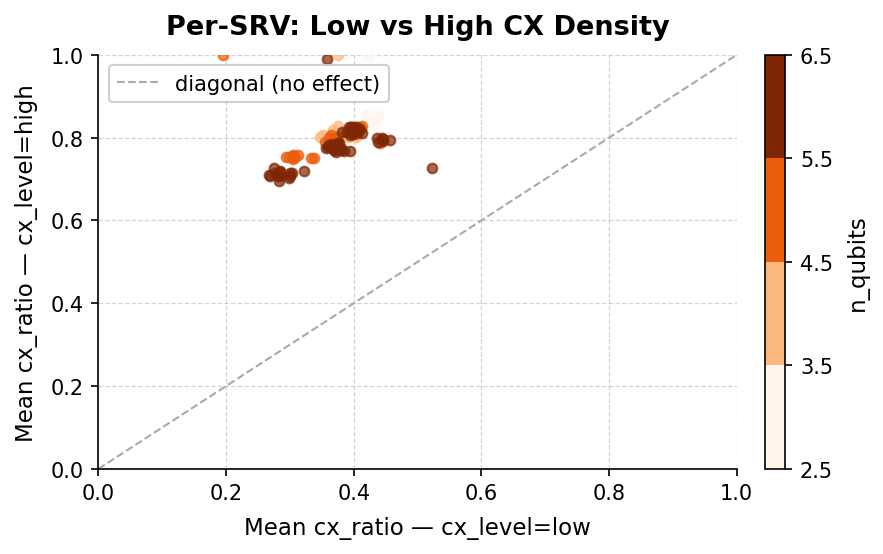

In [10]:
# --- Figure 3: per-SRV scatter — low vs high cx_ratio ---
# Each point is one SRV; x = mean cx_ratio for low condition, y = mean cx_ratio for high condition.
# Points above the diagonal = conditioning works as intended.
cmap_q = plt.get_cmap("Oranges", len(QUBIT_COUNTS))

fig, ax = plt.subplots(figsize=(6, 3.8))
for qi, nq in enumerate(QUBIT_COUNTS):
    for srv in test_srvs:
        if srv_nqubits(srv) != nq:
            continue
        low_mean  = results[srv]["low"]["cx_ratio"].mean()
        high_mean = results[srv]["high"]["cx_ratio"].mean()
        ax.scatter(low_mean, high_mean, color=cmap_q(qi), s=22, alpha=0.7, zorder=3)

lim = [0, 1]
ax.plot(lim, lim, "--", color="#AAAAAA", linewidth=1, label="diagonal (no effect)")
ax.set_xlabel("Mean cx_ratio — cx_level=low")
ax.set_ylabel("Mean cx_ratio — cx_level=high")
ax.set_title("Per-SRV: Low vs High CX Density")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()

sm = mpl.cm.ScalarMappable(
    cmap=cmap_q,
    norm=mpl.colors.BoundaryNorm(np.arange(min(QUBIT_COUNTS) - 0.5, max(QUBIT_COUNTS) + 1.5), cmap_q.N)
)
plt.colorbar(sm, ax=ax, label="n_qubits", fraction=0.046, pad=0.04)
fig.tight_layout()
save_figure(fig, ARTIFACT_DIR / "per_srv_low_vs_high.png")
plt.show()

In [11]:
# --- Save all results ---
save_pickle(dict(results), ARTIFACT_DIR / "results.pkl")
save_json({
    "finetuned_model": FINETUNED_MODEL_DIR,
    "qubit_counts": QUBIT_COUNTS,
    "samples_per_srv": SAMPLES_PER_SRV,
    "guidance_scale": GUIDANCE_SCALE,
    "conditions": CONDITIONS,
    "n_srvs_tested": len(test_srvs),
    "accuracy_by_condition": acc_df.groupby("condition")["accuracy"].mean().round(4).to_dict(),
    "mean_cx_ratio_by_condition": cx_df.groupby("condition")["mean_cx_ratio"].mean().round(4).to_dict(),
}, ARTIFACT_DIR / "summary.json")

print(f"Artifacts saved to {ARTIFACT_DIR}")

# Final summary
print("\n=== Summary ===")
print("Accuracy:")
print(acc_df.groupby("condition")["accuracy"].mean().loc[CONDITIONS].round(4).to_string())
print("\nMean cx_ratio:")
print(cx_df.groupby("condition")["mean_cx_ratio"].mean().loc[CONDITIONS].round(4).to_string())
print("\nMean n_cx:")
print(cx_df.groupby("condition")["mean_n_cx"].mean().loc[CONDITIONS].round(2).to_string())

Artifacts saved to /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/srv-noise-conditioning/cx_level_eval

=== Summary ===
Accuracy:
condition
baseline    0.0663
low         0.9115
medium      0.8664
high        0.9562

Mean cx_ratio:
condition
baseline    0.6994
low         0.3661
medium      0.6321
high        0.7896

Mean n_cx:
condition
baseline    13.52
low          2.94
medium      13.06
high         6.33


/tmp/ipykernel_554412/2440484719.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["n_correct"].sum() / g["n_total"].sum() if g["n_total"].sum() > 0 else 0.0)


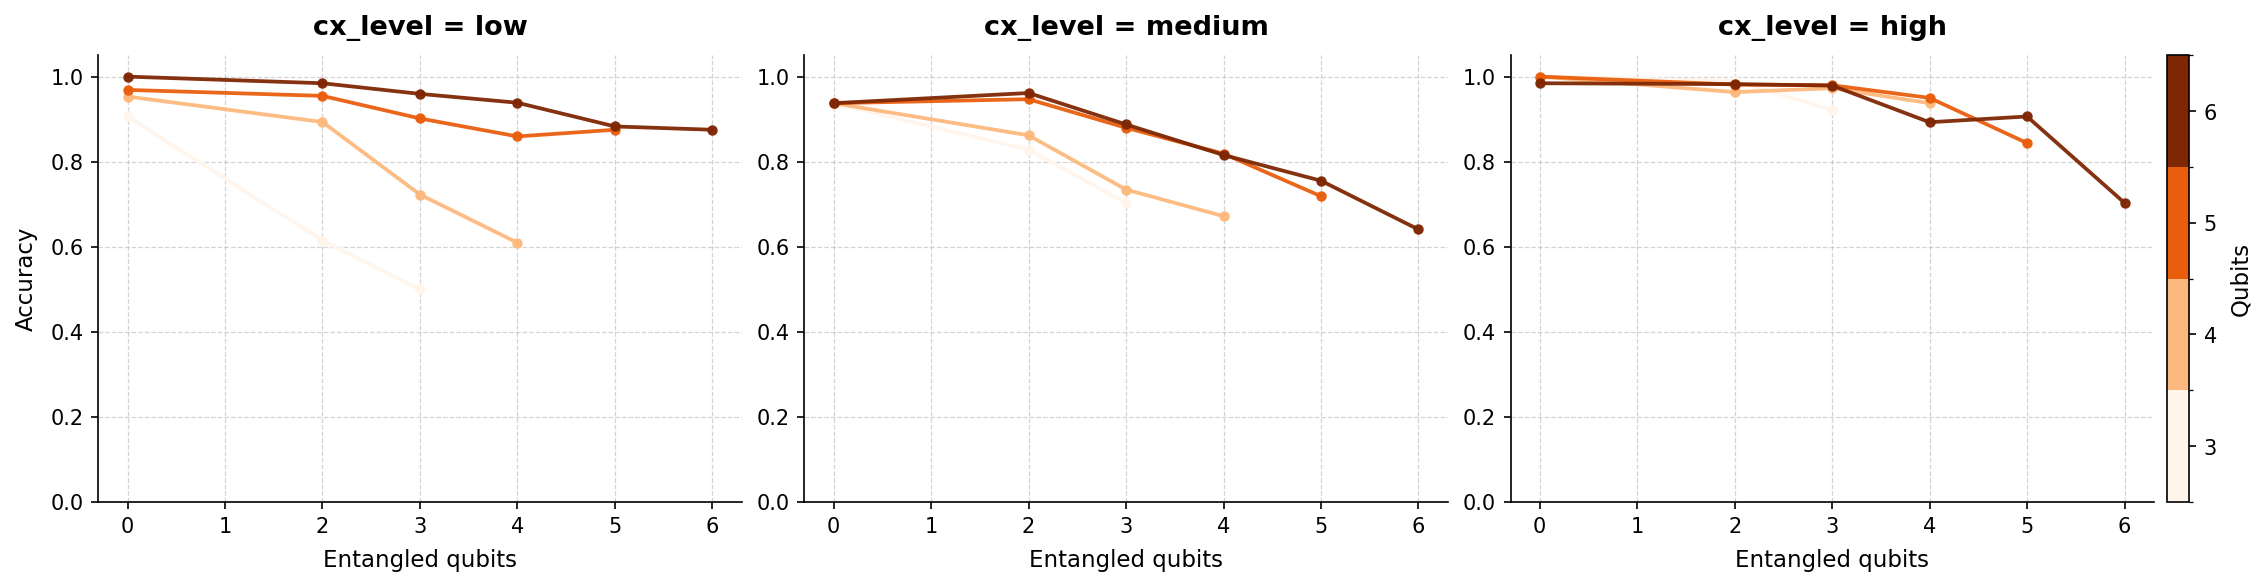

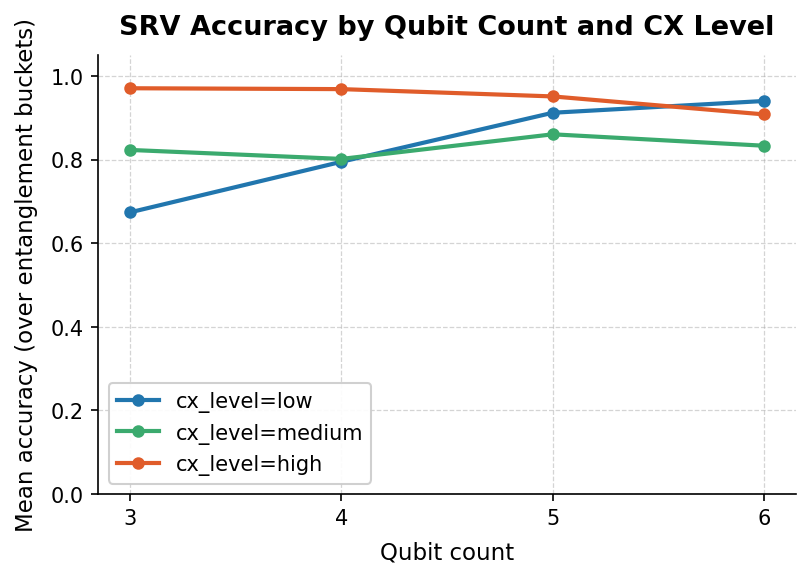

In [12]:
# --- Figure 4: paper-style accuracy plots per cx_level ---
# Mirrors the genQC paper figure: x = n_entangled qubits, y = accuracy,
# one line per qubit count (Oranges colormap). One subplot per cx_level condition.

def n_entangled(srv_str):
    bracket = srv_str[srv_str.find("["):srv_str.find("]")+1]
    return sum(1 for v in ast.literal_eval(bracket) if v == 2)

acc_df["n_entangled"] = acc_df["srv"].apply(n_entangled)

# Weighted accuracy per (condition, n_qubits, n_entangled)
ent_acc = (
    acc_df.groupby(["condition", "n_qubits", "n_entangled"])
    .apply(lambda g: g["n_correct"].sum() / g["n_total"].sum() if g["n_total"].sum() > 0 else 0.0)
    .reset_index(name="accuracy")
)

# Paper-style figure: one subplot per conditioned cx_level
PLOT_CONDITIONS = ["low", "medium", "high"]   # exclude baseline (artefact of fine-tuning)
qubits    = sorted(QUBIT_COUNTS)
cmap_q    = plt.get_cmap("Oranges", len(qubits))
bounds    = np.arange(min(qubits) - 0.5, max(qubits) + 1.5)
norm_q    = mpl.colors.BoundaryNorm(bounds, cmap_q.N)

fig, axes = plt.subplots(1, len(PLOT_CONDITIONS), figsize=(5 * len(PLOT_CONDITIONS), 3.8),
                          constrained_layout=True)

for ax, cond in zip(axes, PLOT_CONDITIONS):
    sub = ent_acc[ent_acc["condition"] == cond]
    for q in qubits:
        row = sub[sub["n_qubits"] == q].sort_values("n_entangled")
        if row.empty:
            continue
        ax.plot(
            row["n_entangled"].values,
            row["accuracy"].values,
            marker="o", markersize=4, linewidth=1.8,
            color=cmap_q(norm_q(q)), alpha=0.95,
        )
    ax.set_xlabel("Entangled qubits")
    ax.set_ylabel("Accuracy" if cond == PLOT_CONDITIONS[0] else "")
    ax.set_title(f"cx_level = {cond}")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(0, max(qubits) + 1))

# Shared colorbar
sm = mpl.cm.ScalarMappable(norm=norm_q, cmap=cmap_q)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], pad=0.02, ticks=qubits, boundaries=bounds, fraction=0.046)
cbar.set_label("Qubits")

save_figure(fig, ARTIFACT_DIR / "accuracy_by_entanglement_per_cx_level.png")
plt.show()

# Also: single comparison figure — mean accuracy across entanglement buckets per qubit count
fig2, ax2 = plt.subplots(figsize=(6, 3.8))
for cond in PLOT_CONDITIONS:
    sub = ent_acc[ent_acc["condition"] == cond]
    means = sub.groupby("n_qubits")["accuracy"].mean().reindex(qubits)
    ax2.plot(qubits, means.values, marker="o", markersize=5, linewidth=2,
             color=COLORS[cond], label=f"cx_level={cond}")

ax2.set_xlabel("Qubit count")
ax2.set_ylabel("Mean accuracy (over entanglement buckets)")
ax2.set_title("SRV Accuracy by Qubit Count and CX Level")
ax2.set_xticks(qubits)
ax2.set_ylim(0, 1.05)
ax2.legend()

save_figure(fig2, ARTIFACT_DIR / "mean_accuracy_by_qubit_count.png")
plt.show()